In [1]:
pip install pandas numpy scikit-learn xgboost matplotlib seaborn


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [31]:
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/elavarasan/Downloads/Projects/thyroid_cancer/dataset.csv")

# Clean column names
df.columns = df.columns.str.strip()

print(df.head())

   Age Gender Smoking Hx Smoking Hx Radiothreapy Thyroid Function  \
0   27      F      No         No              No        Euthyroid   
1   34      F      No        Yes              No        Euthyroid   
2   30      F      No         No              No        Euthyroid   
3   62      F      No         No              No        Euthyroid   
4   62      F      No         No              No        Euthyroid   

          Physical Examination Adenopathy       Pathology     Focality Risk  \
0   Single nodular goiter-left         No  Micropapillary    Uni-Focal  Low   
1          Multinodular goiter         No  Micropapillary    Uni-Focal  Low   
2  Single nodular goiter-right         No  Micropapillary    Uni-Focal  Low   
3  Single nodular goiter-right         No  Micropapillary    Uni-Focal  Low   
4          Multinodular goiter         No  Micropapillary  Multi-Focal  Low   

     T   N   M Stage       Response Recurred  
0  T1a  N0  M0     I  Indeterminate       No  
1  T1a  N0  M0  

In [32]:
print(df["Recurred"].value_counts())

Recurred
No     275
Yes    108
Name: count, dtype: int64


In [35]:
# Separate numeric & categorical properly
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include='object').columns

# Fill values
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

/var/folders/5w/ll5h_81967x9lg1djbqnqk900000gn/T/ipykernel_828/4157137002.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [36]:
# Separate target BEFORE encoding
y = df["Recurred"]

# Encode target safely
le_target = LabelEncoder()
y = le_target.fit_transform(y)

# Features
X = df.drop("Recurred", axis=1)

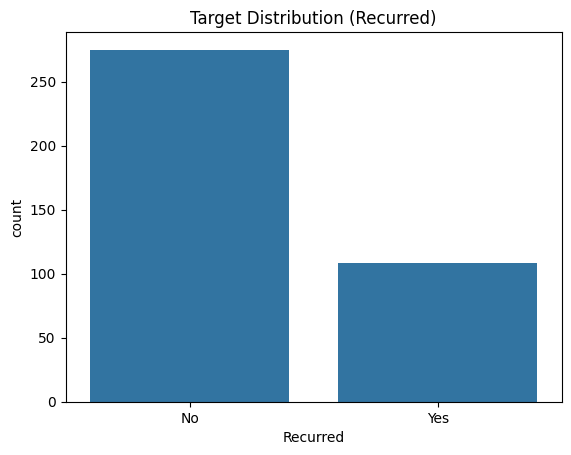

In [46]:
# Target distribution
sns.countplot(x=df["Recurred"])
plt.title("Target Distribution (Recurred)")
plt.show()

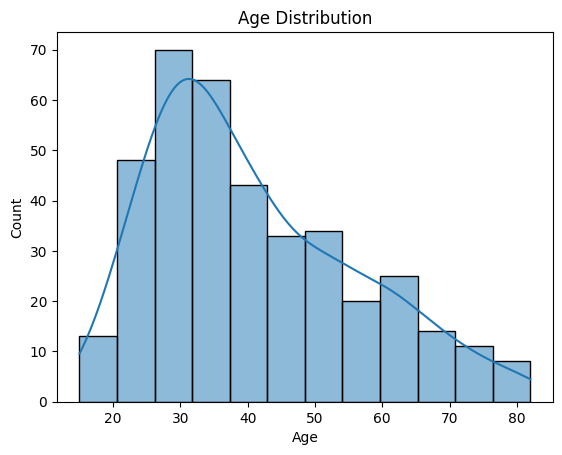

In [47]:
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

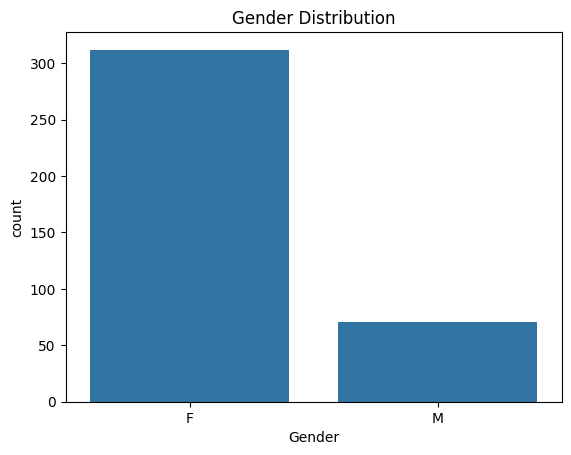

In [48]:
sns.countplot(x=df["Gender"])
plt.title("Gender Distribution")
plt.show()

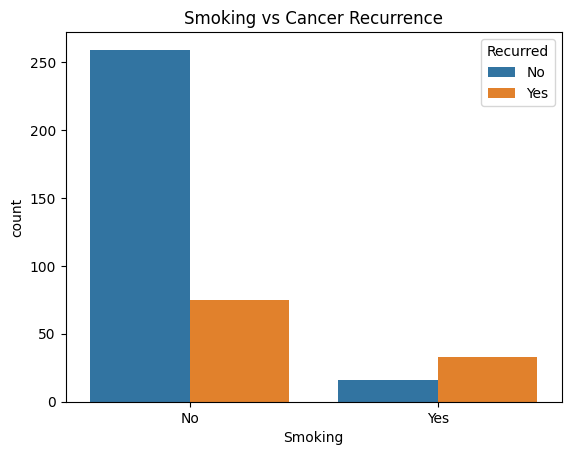

In [49]:
sns.countplot(x="Smoking", hue="Recurred", data=df)
plt.title("Smoking vs Cancer Recurrence")
plt.show()

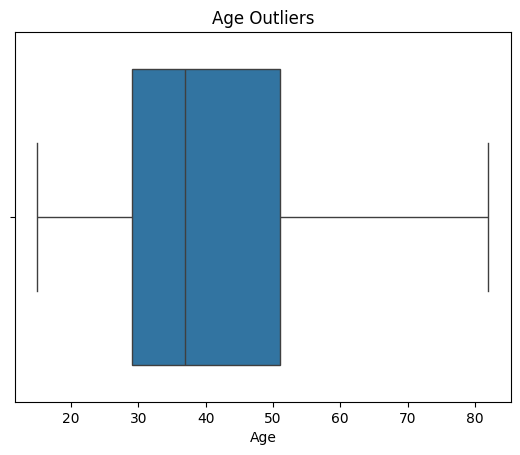

In [51]:
sns.boxplot(x=df["Age"])
plt.title("Age Outliers")
plt.show()

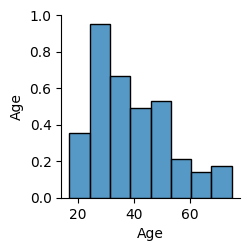

In [52]:
sns.pairplot(df.sample(100))  # use sample for speed
plt.show()

In [37]:
le_dict = {}

for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        le_dict[col] = le

In [38]:
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')
    X[col] = X[col].fillna(X[col].mean())

print(X.dtypes)

Age                       int64
Gender                  float64
Smoking                 float64
Hx Smoking              float64
Hx Radiothreapy         float64
Thyroid Function        float64
Physical Examination    float64
Adenopathy              float64
Pathology               float64
Focality                float64
Risk                    float64
T                       float64
N                       float64
M                       float64
Stage                   float64
Response                float64
dtype: object


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y   
)

In [40]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [41]:
y_pred = model.predict(X_test)

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7532467532467533

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.89      0.84        55
           1       0.60      0.41      0.49        22

    accuracy                           0.75        77
   macro avg       0.70      0.65      0.66        77
weighted avg       0.74      0.75      0.74        77



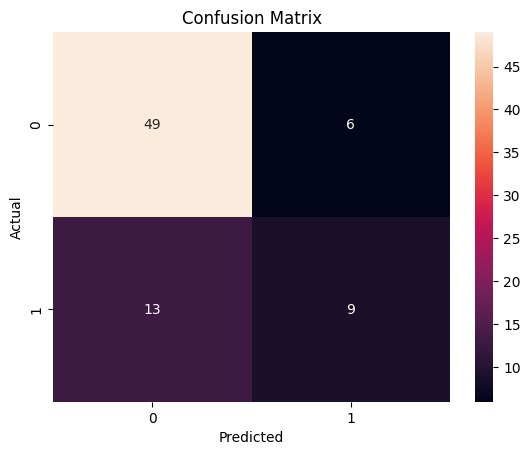

In [43]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [44]:
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 0.761437908496732
Test Accuracy: 0.7532467532467533


                 Feature  Importance
0                    Age         1.0
1                 Gender         0.0
2                Smoking         0.0
3             Hx Smoking         0.0
4        Hx Radiothreapy         0.0
5       Thyroid Function         0.0
6   Physical Examination         0.0
7             Adenopathy         0.0
8              Pathology         0.0
9               Focality         0.0
10                  Risk         0.0
11                     T         0.0
12                     N         0.0
13                     M         0.0
14                 Stage         0.0
15              Response         0.0


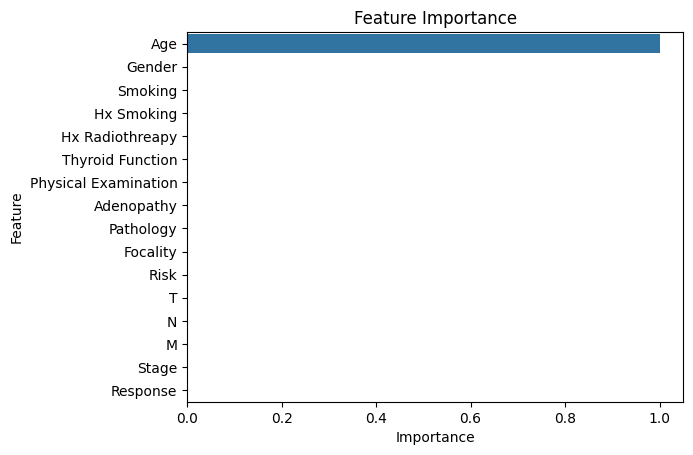

In [45]:
importances = model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_df)

sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importance")
plt.show()